In [ ]:
import pandas as pd
import re
import os
import paramiko
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from itertools import combinations
from pprint import pprint
from itertools import chain
from sqlalchemy import create_engine

In [ ]:
data = pd.read_csv("/Users/glj523/Library/CloudStorage/OneDrive-UniversityofCopenhagen/all_qc_data_ill_comp.csv")
data = data.drop(columns=["Unnamed: 0"])

In [67]:
singleton_filter = data[data["qc_type"].str.contains("singleton")]["qc_type"].unique()

In [68]:
singleton_filter

array(['L001_singleton', 'L002_singleton', 'L003_singleton',
       'L004_singleton', 'L006_singleton', 'L005_singleton',
       'L008_singleton'], dtype=object)

In [77]:
data_ns6 = data[data["Platform"] == "NovaSeq6"]
data_nsX = data[data["Platform"] == "NovaSeqX"]

In [99]:
gb = data_ns6[["qc_type", "fastqc_raw__Total Sequences"]].groupby("qc_type").sum().reset_index()
gb[gb["fastqc_raw__Total Sequences"] > 0]

,qc_type,fastqc_raw__Total Sequences
1,L001_R1,5.535169e+09
2,L001_R2,5.535169e+09
6,L002_R1,5.592592e+09
7,L002_R2,5.592592e+09
11,L003_R1,5.539237e+09
12,L003_R2,5.539237e+09
16,L004_R1,5.577413e+09
17,L004_R2,5.577413e+09


In [100]:
gb[gb["fastqc_raw__Total Sequences"] > 0].sum()["fastqc_raw__Total Sequences"] / 1e9

44.488821618

In [101]:
gb = data_nsX[["qc_type", "fastqc_raw__Total Sequences"]].groupby("qc_type").sum().reset_index()
gb[gb["fastqc_raw__Total Sequences"] > 0]

,qc_type,fastqc_raw__Total Sequences
1,L001_R1,4.586675e+09
2,L001_R2,4.586675e+09
6,L005_R1,5.688910e+09
7,L005_R2,5.688910e+09
11,L006_R1,4.665162e+09
12,L006_R2,4.665162e+09
16,L008_R1,5.691308e+09
17,L008_R2,5.691308e+09


In [103]:
gb[gb["fastqc_raw__Total Sequences"] > 0].sum()["fastqc_raw__Total Sequences"] / 1e9

41.264111494

In [115]:
gb = data_nsX[["qc_type", "fastqc_trimmed__Total Sequences"]].groupby("qc_type").sum().reset_index()
gb = gb[gb["fastqc_trimmed__Total Sequences"] > 0]

In [116]:
gb[gb["qc_type"].str.contains("collapsed")].sum()

qc_type                            L001_collapsedL005_collapsedL006_collapsedL008...
fastqc_trimmed__Total Sequences                                        14958920761.0
dtype: object

In [117]:
gb["Lane"] = gb["qc_type"].apply(lambda x: x.split("_")[0])
gb["Read"] = gb["qc_type"].apply(lambda x: x.split("_")[1])


<Axes: xlabel='qc_type'>

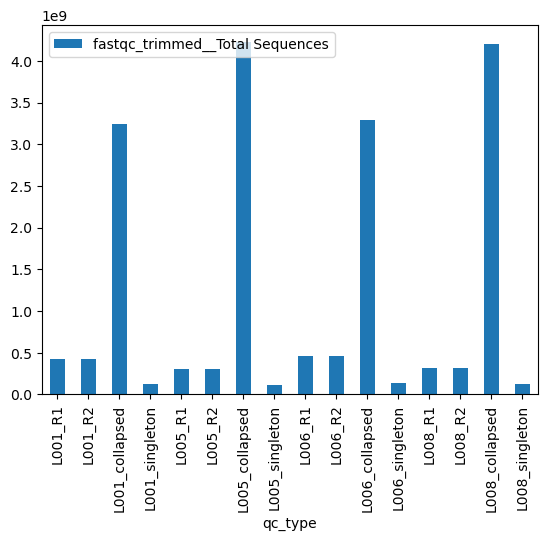

In [122]:
gb[["qc_type", "fastqc_trimmed__Total Sequences"]].plot(kind="bar", x="qc_type")

In [114]:
gb[["fastqc_trimmed__Total Sequences", "Lane"]]

,fastqc_trimmed__Total Sequences,Lane
1,4.290355e+08,L001
2,4.290355e+08,L001
3,3.247229e+09,L001
4,1.252135e+08,L001
6,3.048800e+08,L005
7,3.048800e+08,L005
8,4.220194e+09,L005
9,1.156861e+08,L005
11,4.622937e+08,L006
12,4.622937e+08,L006


<Axes: xlabel='Lane'>

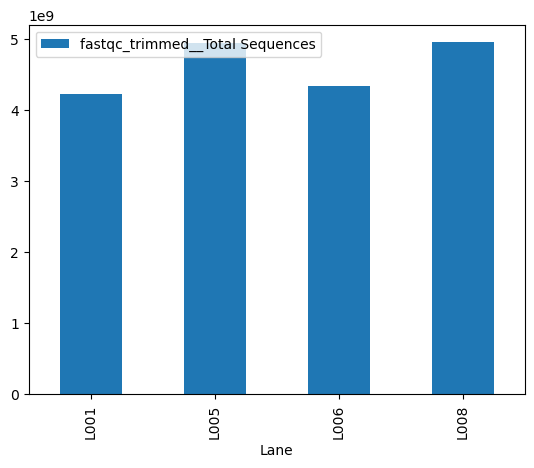

In [111]:
gb[["fastqc_trimmed__Total Sequences", "Lane"]].groupby("Lane").sum().plot(kind="bar")

In [ ]:
gb = data_nsX[["qc_type", "fastqc_trimmed__Total Sequences"]].groupby("qc_type").sum().reset_index()
gb = gb[gb["fastqc_trimmed__Total Sequences"] > 0]

,qc_type,fastqc_raw__Total Sequences
0,L001,0.000000e+00
1,L001_R1,1.012184e+10
2,L001_R2,1.012184e+10
3,L001_collapsed,0.000000e+00
4,L001_singleton,0.000000e+00
5,L002,0.000000e+00
6,L002_R1,5.592592e+09
7,L002_R2,5.592592e+09
8,L002_collapsed,0.000000e+00
9,L002_singleton,0.000000e+00


In [72]:
gb.reset_index()


,qc_type,fastqc_raw__Total Sequences
0,L001,0.000000e+00
1,L001_R1,1.012184e+10
2,L001_R2,1.012184e+10
3,L001_collapsed,0.000000e+00
4,L001_singleton,0.000000e+00
5,L002,0.000000e+00
6,L002_R1,5.592592e+09
7,L002_R2,5.592592e+09
8,L002_collapsed,0.000000e+00
9,L002_singleton,0.000000e+00


<Axes: xlabel='library_id'>

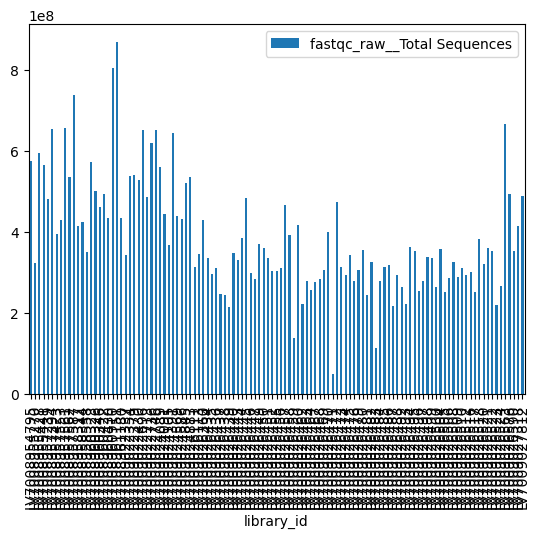

In [55]:
data[data["Platform"] == "NovaSeq6"][["library_id", "fastqc_raw__Total Sequences"]].groupby("library_id").sum().plot(kind="bar")

In [ ]:
set(data[data["Platform"] == "NovaSeqX"]["qc_type"])

In [ ]:
data[data["Platform"] == "NovaSeq6"]["fas"]

In [ ]:
set(data[data["Platform"] == "NovaSeq6"]["qc_type"])

In [ ]:
for col in data.columns:
    print(col)

In [ ]:
pd.set_option('display.max_rows', 300)
pd.set_option('display.max_columns', 300)

data[data["library_id"] == "LV7008954795"]

In [ ]:
set(data[(data["Platform"] == "NovaSeq6")]["qc_type"])

In [ ]:
set(data[data["Platform"] == "NovaSeqX"]["qc_type"])

In [ ]:
for col in data.columns:
    print(col)

In [ ]:
set(data[data["Platform"] == "NovaSeq6"]["library_id"]) == set(data[data["Platform"] == "NovaSeqX"]["library_id"])

In [ ]:
len(set(data[(data["Platform"] == "NovaSeq6") & (data["Protocol"] == "Double")]["library_id"]))

In [ ]:
len(set(data[(data["Platform"] == "NovaSeqX") & (data["Protocol"] == "Double")]["library_id"]))

In [ ]:
len(set(data[(data["Platform"] == "NovaSeq6") & (data["Protocol"] == "Single")]["library_id"]))

In [ ]:
len(set(data[(data["Platform"] == "NovaSeqX") & (data["Protocol"] == "Single")]["library_id"]))

In [ ]:
plt.scatter(data["fastqc_raw__Total Sequences"], data['fastqc_trimmed__Total Sequences'])
plt.xlabel('X-axis label')
plt.ylabel('Y-axis label')
plt.title('Scatter plot of X vs Y')
plt.show()

In [58]:
data["eDNA Concentration"].unique()

array(['Unknown?', '110pM', '110pMrep', '310pM', '310pMrep'], dtype=object)

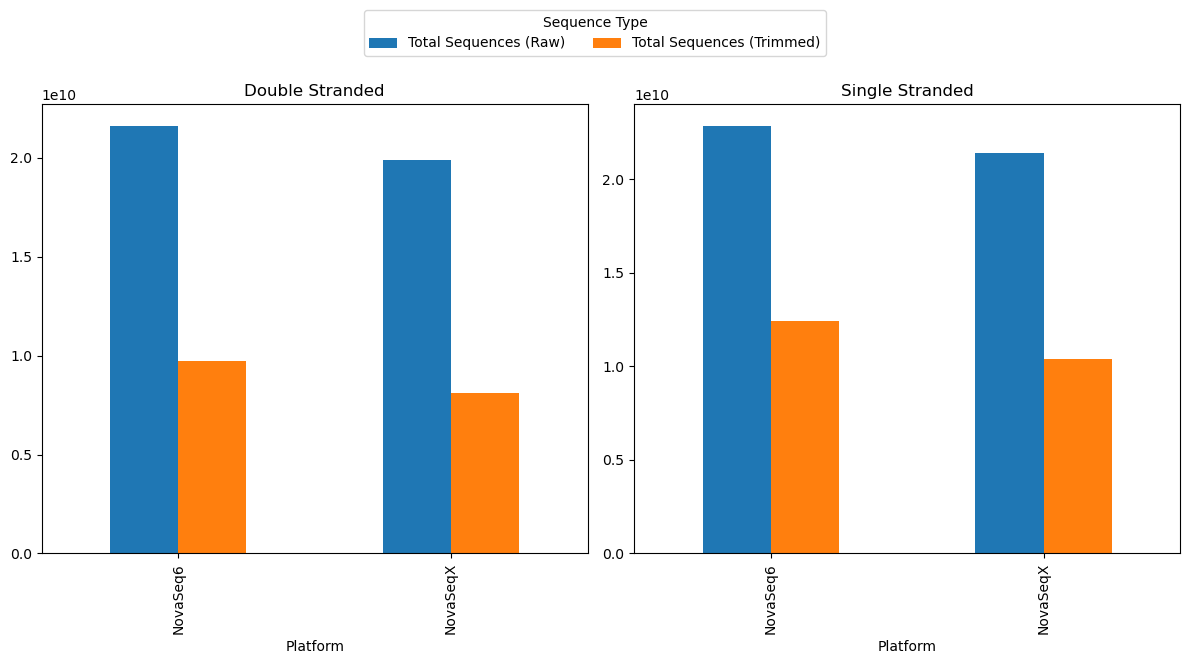

In [56]:
def make_sum_plot_1(column1, column2, combined_df):
    combined_df[column1] = combined_df[column1].astype(float)
    combined_df[column2] = combined_df[column2].astype(float)

    double_df = combined_df[combined_df['Protocol'] == 'Double']
    single_df = combined_df[combined_df['Protocol'] == 'Single']
    # Calculate mean values for each platform and each sequencing type
    raw_sum_double = double_df.groupby('Platform')[column1].sum()

    trimmed_sum_double = double_df.groupby('Platform')[column2].sum()

    raw_sum_single = single_df.groupby('Platform')[column1].sum()

    trimmed_sum_single = single_df.groupby('Platform')[column2].sum()

    # Combine data into a DataFrame for easier plotting
    combined_sums_double = pd.DataFrame({
        'Total Sequences (Raw)': raw_sum_double,
        'Total Sequences (Trimmed)': trimmed_sum_double
    })

    # Combine data into a DataFrame for easier plotting
    combined_sums_single = pd.DataFrame({
        'Total Sequences (Raw)': raw_sum_single,
        'Total Sequences (Trimmed)': trimmed_sum_single
    })

    # Plotting
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    combined_sums_double.plot(kind='bar', ax=ax[0], title="Double Stranded", legend=False)
    combined_sums_single.plot(kind='bar', ax=ax[1], title="Single Stranded", legend=False)

    handles, labels = ax[1].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 1.01), ncol=2, title="Sequence Type")

    plt.tight_layout()
    plt.show()


make_sum_plot_1('fastqc_raw__Total Sequences', 'fastqc_trimmed__Total Sequences', data)


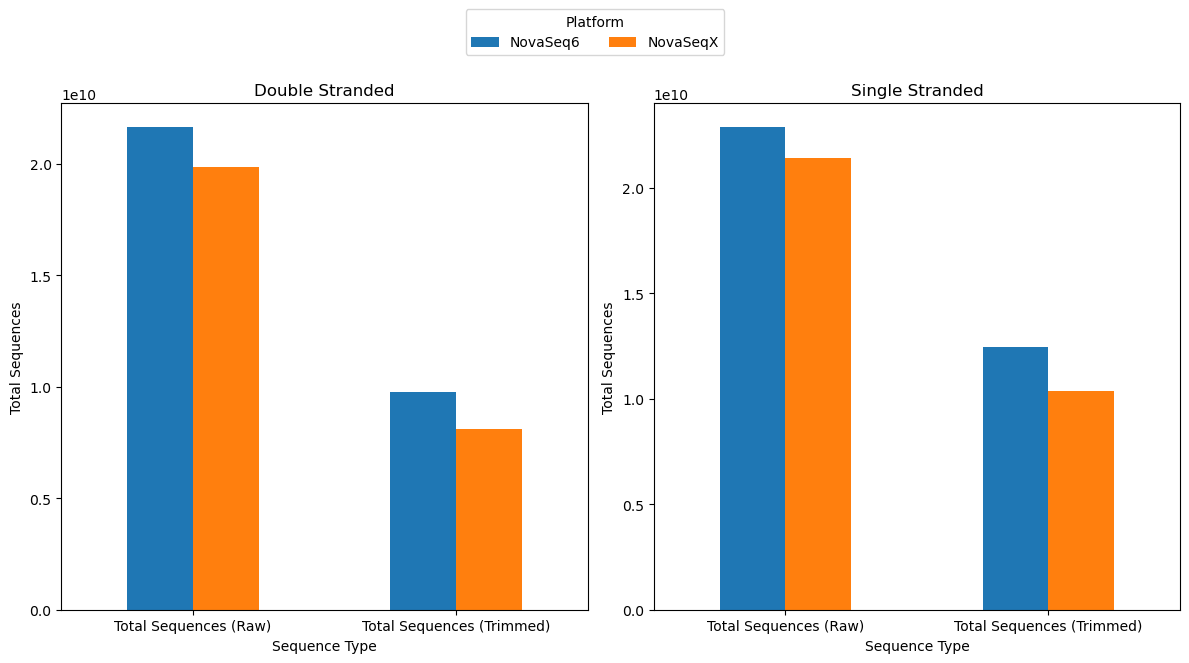

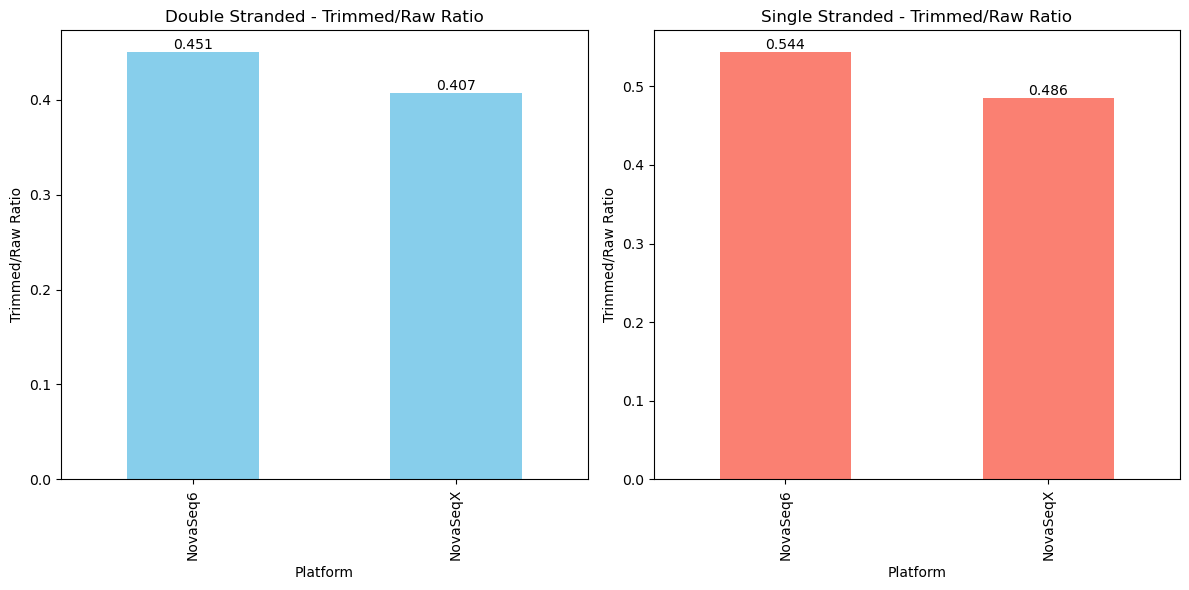

In [57]:
def plot2(double_data, single_data):
    double_df = double_data
    single_df = single_data
    # Calculate mean values for each platform and each sequencing type
    raw_sum_double = double_df.groupby('Platform')['fastqc_raw__Total Sequences'].sum()
    trimmed_sum_double = double_df.groupby('Platform')['fastqc_trimmed__Total Sequences'].sum()

    raw_sum_single = single_df.groupby('Platform')['fastqc_raw__Total Sequences'].sum()
    trimmed_sum_single = single_df.groupby('Platform')['fastqc_trimmed__Total Sequences'].sum()

    # Combine data into a DataFrame for easier plotting
    combined_sums_double = pd.DataFrame({
        'Total Sequences (Raw)': raw_sum_double,
        'Total Sequences (Trimmed)': trimmed_sum_double
    }).reset_index().melt(id_vars='Platform', var_name='Sequence Type', value_name='Total Sequences')

    combined_sums_single = pd.DataFrame({
        'Total Sequences (Raw)': raw_sum_single,
        'Total Sequences (Trimmed)': trimmed_sum_single
    }).reset_index().melt(id_vars='Platform', var_name='Sequence Type', value_name='Total Sequences')

    # Plotting
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))

    # Plot for Double Stranded
    combined_sums_double.pivot(index='Sequence Type', columns='Platform', values='Total Sequences').plot(kind='bar', ax=ax[0], rot=0, legend=False)
    ax[0].set_title("Double Stranded")
    ax[0].set_ylabel("Total Sequences")

    # Plot for Single Stranded
    combined_sums_single.pivot(index='Sequence Type', columns='Platform', values='Total Sequences').plot(kind='bar', ax=ax[1], rot=0, legend=False)
    ax[1].set_title("Single Stranded")
    ax[1].set_ylabel("Total Sequences")

    # Adding legend
    handles, labels = ax[1].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 1.01), ncol=2, title="Platform")

    plt.tight_layout()
    plt.show()

    
    # Calculate the ratio of trimmed to raw sequences
    ratio_double = (trimmed_sum_double / raw_sum_double).reset_index(name='Trimmed/Raw Ratio')
    ratio_single = (trimmed_sum_single / raw_sum_single).reset_index(name='Trimmed/Raw Ratio')

    # Plotting
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))

    # Plot for Double Stranded ratios
    ratio_double.plot(kind='bar', x='Platform', y='Trimmed/Raw Ratio', ax=ax[0], color='skyblue', legend=False)
    ax[0].set_title("Double Stranded - Trimmed/Raw Ratio")
    ax[0].set_ylabel("Trimmed/Raw Ratio")
    ax[0].set_xlabel("Platform")

    # Annotate the bars with the ratio values
    for i, value in enumerate(ratio_double['Trimmed/Raw Ratio']):
        ax[0].text(i, value, f"{value:.3f}", ha='center', va='bottom')

    # Plot for Single Stranded ratios
    ratio_single.plot(kind='bar', x='Platform', y='Trimmed/Raw Ratio', ax=ax[1], color='salmon', legend=False)
    ax[1].set_title("Single Stranded - Trimmed/Raw Ratio")
    ax[1].set_ylabel("Trimmed/Raw Ratio")
    ax[1].set_xlabel("Platform")

    # Annotate the bars with the ratio values
    for i, value in enumerate(ratio_single['Trimmed/Raw Ratio']):
        ax[1].text(i, value, f"{value:.3f}", ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

plot2(data[data["Protocol"] == "Double"], data[data["Protocol"] == "Single"])


In [ ]:
def make_boxplots(data, data_types, platforms, title, ax):
    gc_data = []
    labels = []

    for platform in platforms:
        for data_type in data_types:
            gc_content = data[data['Platform'] == platform][data_type].dropna()
            gc_data.append(gc_content)
            labels.append(f'{platform} {"Raw" if "raw" in data_type else "Trimmed"}')
    
    ax.boxplot(gc_data, tick_labels=labels)
    ax.set_title(title)
    ax.set_ylabel('%GC Content')

# Set up the plot
fig, axs = plt.subplots(1, 2, figsize=(15, 7))

# Platforms
platforms = data["Platform"].unique()

describe_cols = [r"fastqc_raw__%GC", r"fastqc_trimmed__%GC"]

# Plot GC content for double-stranded and single-stranded sequencing
make_boxplots(data[data["Protocol"] == "Double"], describe_cols, platforms, 'Double-Stranded Sequencing GC Content', axs[0])
make_boxplots(data[data["Protocol"] == "Single"], describe_cols, platforms, 'Single-Stranded Sequencing GC Content', axs[1])

# Display the plot
plt.suptitle('GC Content Comparison by Platform and Strand Type')
plt.tight_layout()
plt.show()

    